# 실습 내용

- K-Fold Cross Validation을 사용해 모델의 성능을 예측한다.

# 1.환경 준비

In [29]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

In [30]:
# 데이터 읽어오기
path = 'data/mobile_cust_churn.csv'
df = pd.read_csv(path)

# 2.데이터 이해

In [31]:
# 데이터 살펴보기
df.head()

,id,COLLEGE,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION,REPORTED_SATISFACTION,REPORTED_USAGE_LEVEL,CONSIDERING_CHANGE_OF_PLAN,CHURN
0,1,0,31953,0,6,313378,161,0,4,unsat,little,no,STAY
1,2,1,36147,0,13,800586,244,0,6,unsat,little,considering,STAY
2,3,1,27273,230,0,305049,201,16,15,unsat,very_little,perhaps,STAY
3,4,0,120070,38,33,788235,780,3,2,unsat,very_high,considering,LEAVE
4,5,1,29215,208,85,224784,241,21,1,very_unsat,little,never_thought,STAY


**데이터 설명**

- COLLEGE: 대학 졸업여부
- INCOME: 연수입
- OVERAGE: 월평균 초과사용 시간(분)
- LEFTOVER: 월평균 잔여시간비율(%)
- HOUSE: 집값
- HANDSET_PRICE: 스마트폰 가격
- OVER_15MINS_CALLS_PER_MONTH: 월평균 장기통화(15분이상) 횟수
- AVERAGE_CALL_DURATION: 평균 통화 시간
- REPORTED_SATISFACTION: 만족도 설문조사 결과
- REPORTED_USAGE_LEVEL: 사용도 자가진단 결과
- CONSIDERING_CHANGE_OF_PLAN: 향후 변경계획 설문조사 결과
- CHURN: 이탈(번호이동) 여부 (Target 변수)

In [32]:
# 기술통계 확인
df.describe()

,id,COLLEGE,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,0.502400,80281.447750,85.979550,23.898650,493155.264250,389.615100,8.000700,6.002250
std,5773.647028,0.500007,41680.586319,85.992324,26.816645,252407.884692,213.820682,8.925418,4.402558
min,1.000000,0.000000,20007.000000,-2.000000,0.000000,150002.000000,130.000000,0.000000,1.000000
25%,5000.750000,0.000000,42217.000000,0.000000,0.000000,263714.250000,219.000000,1.000000,2.000000
50%,10000.500000,1.000000,75366.500000,59.000000,14.000000,452259.500000,326.000000,4.000000,5.000000
75%,15000.250000,1.000000,115881.750000,179.000000,41.000000,702378.000000,533.250000,15.000000,10.000000
max,20000.000000,1.000000,159983.000000,335.000000,89.000000,999996.000000,899.000000,29.000000,15.000000


# 3.데이터 전처리

**1) 변수 제거**

In [33]:
# 제거 대상: id
drop_cols = ['id']

# 변수 제거
df.drop(drop_cols, axis=1, inplace=True)

# 확인
df.head()

,COLLEGE,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION,REPORTED_SATISFACTION,REPORTED_USAGE_LEVEL,CONSIDERING_CHANGE_OF_PLAN,CHURN
0,0,31953,0,6,313378,161,0,4,unsat,little,no,STAY
1,1,36147,0,13,800586,244,0,6,unsat,little,considering,STAY
2,1,27273,230,0,305049,201,16,15,unsat,very_little,perhaps,STAY
3,0,120070,38,33,788235,780,3,2,unsat,very_high,considering,LEAVE
4,1,29215,208,85,224784,241,21,1,very_unsat,little,never_thought,STAY


**2) x, y 분리**

In [34]:
# Target 설정
target = 'CHURN'

# 데이터 분리
X = df.drop(target, axis=1)
y = df[target]


**3) 가변수화**

In [35]:
# 가변수화 대상: REPORTED_SATISFACTION, REPORTED_USAGE_LEVEL, CONSIDERING_CHANGE_OF_PLAN
df_dummies = ['REPORTED_SATISFACTION', 'REPORTED_USAGE_LEVEL', 'CONSIDERING_CHANGE_OF_PLAN']

# 가변수화
X = pd.get_dummies(X, columns=df_dummies, drop_first=True)

# 확인
X.head()

,COLLEGE,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION,REPORTED_SATISFACTION_sat,REPORTED_SATISFACTION_unsat,REPORTED_SATISFACTION_very_sat,REPORTED_SATISFACTION_very_unsat,REPORTED_USAGE_LEVEL_high,REPORTED_USAGE_LEVEL_little,REPORTED_USAGE_LEVEL_very_high,REPORTED_USAGE_LEVEL_very_little,CONSIDERING_CHANGE_OF_PLAN_considering,CONSIDERING_CHANGE_OF_PLAN_never_thought,CONSIDERING_CHANGE_OF_PLAN_no,CONSIDERING_CHANGE_OF_PLAN_perhaps
0,0,31953,0,6,313378,161,0,4,False,True,False,False,False,True,False,False,False,False,True,False
1,1,36147,0,13,800586,244,0,6,False,True,False,False,False,True,False,False,True,False,False,False
2,1,27273,230,0,305049,201,16,15,False,True,False,False,False,False,False,True,False,False,False,True
3,0,120070,38,33,788235,780,3,2,False,True,False,False,False,False,True,False,True,False,False,False
4,1,29215,208,85,224784,241,21,1,False,False,False,True,False,True,False,False,False,True,False,False


**4) 학습용, 평가용 데이터 분리**

In [36]:
# 모듈 불러오기
from sklearn.model_selection import train_test_split

# 7:3으로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.7,
                                                    random_state=1)

**5) 정규화**

In [41]:
# 모듈 불러오기
from sklearn.preprocessing import MinMaxScaler

# 정규화
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)




# 4.성능 예측

- K분할 교차 검증 방법으로 모델 성능을 예측
- `cross_val_score(model, x_train, y_train, cv=n)` 형태로 사용
- cv 옵션에 k값(분할 개수, 기본값=5)을 지정
- cross_val_score 함수는 넘파이 배열 형태의 값을 반환
- cross_val_score 함수 반환 값의 평균을 해당 모델의 예측 성능으로 볼 수 있다.


**1) KNN**

In [43]:
# 불러오기
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# 선언하기
model_knn = KNeighborsClassifier()

# 검증하기
cv_score = cross_val_score(model_knn, X_train_s, y_train, cv=10, scoring='accuracy')

# 확인
print(cv_score)
print('평균: ', cv_score.mean())            # 모델의 평균 성능 평가(일반적인 성능을 대표하는 값)
print('표준편차: ', cv_score.std())          # 모델 성능의 일관성 평가(표준편차가 작다면 -> 모델이 안정적)

# 성능 정보 수집
result = {}
result['KNN'] = cv_score.mean()

[0.60071429 0.59071429 0.61357143 0.59285714 0.57785714 0.58357143
 0.60214286 0.61357143 0.58857143 0.60928571]
평균:  0.5972857142857143
표준편차:  0.011891516440946723


**2) Decision Tree**

In [44]:
# 불러오기
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# 선언하기
model_dt = DecisionTreeClassifier(max_depth=5, random_state=1)

# 검증하기
cv_score = cross_val_score(model_dt, X_train, y_train, cv=10, scoring='accuracy')

# 확인
print(cv_score)
print('평균: ', cv_score.mean())            # 모델의 평균 성능 평가(일반적인 성능을 대표하는 값)
print('표준편차: ', cv_score.std())          # 모델 성능의 일관성 평가(표준편차가 작다면 -> 모델이 안정적)

# 성능 정보 수집
result['Decision Tree'] = cv_score.mean()

[0.69857143 0.69142857 0.70214286 0.69285714 0.69428571 0.69214286
 0.70857143 0.69142857 0.70428571 0.70285714]
평균:  0.6978571428571428
표준편차:  0.0059418955265958355


**3) Logistic Regression**

In [45]:
# 불러오기
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# 선언하기
model_log = LogisticRegression()

# 검증하기
cv_score = cross_val_score(model_log, X_train_s, y_train, cv=10, scoring='accuracy')

# 확인
print(cv_score)
print('평균: ', cv_score.mean())            # 모델의 평균 성능 평가(일반적인 성능을 대표하는 값)
print('표준편차: ', cv_score.std())          # 모델 성능의 일관성 평가(표준편차가 작다면 -> 모델이 안정적)

# 성능 정보 수집
result['log'] = cv_score.mean()

[0.64142857 0.63785714 0.64       0.64214286 0.62642857 0.64285714
 0.65357143 0.64       0.65571429 0.63142857]
평균:  0.6411428571428572
표준편차:  0.008337277977951347


# 5. 성능 비교

In [46]:
result

{'KNN': np.float64(0.5972857142857143),
 'Decision Tree': np.float64(0.6978571428571428),
 'log': np.float64(0.6411428571428572)}

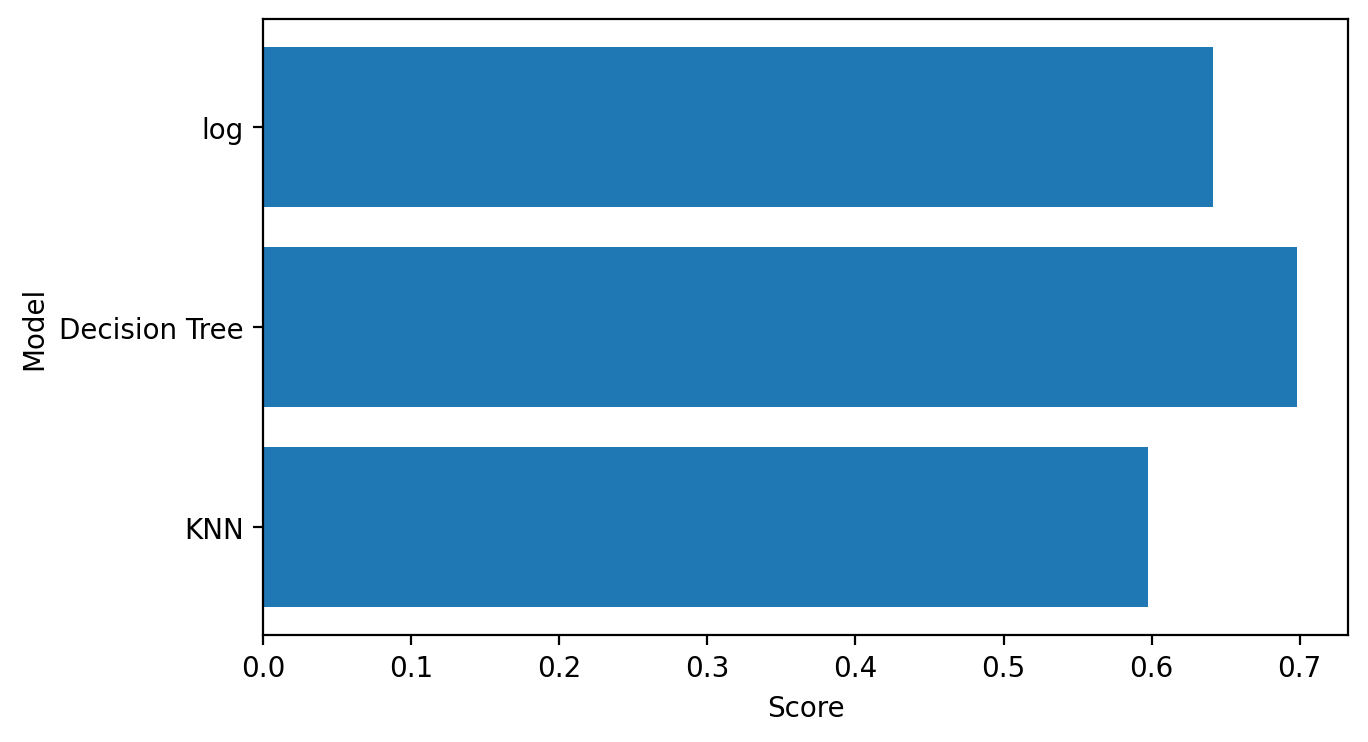

In [47]:
# 시각화
plt.figure(figsize=(7,4))
plt.barh(y=list(result), width=result.values(), data=result)
plt.ylabel('Model')
plt.xlabel('Score')
plt.show()

# 6. 실제 성능 비교

In [50]:
from sklearn.metrics import classification_report

model = DecisionTreeClassifier()
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       LEAVE       0.61      0.63      0.62      2935
        STAY       0.64      0.62      0.63      3065

    accuracy                           0.62      6000
   macro avg       0.62      0.62      0.62      6000
weighted avg       0.63      0.62      0.62      6000

